<a href="https://colab.research.google.com/github/manavdhelia/ML-for-engineers/blob/HW4/hw4_p1a_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECE 601 — HW4 Problem 1(a)
## Neural Network Classifier with One Hidden Layer on MNIST
**UMass Amherst, Spring 2026**

In [1]:
# Install dependencies if needed (uncomment if running for the first time)
# !pip install torch torchvision matplotlib

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

# Show plots inline in the notebook
%matplotlib inline

print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')

PyTorch version : 2.10.0+cpu
CUDA available  : False


In [2]:
# ── Reproducibility ────────────────────────────────────────────────────────
torch.manual_seed(42)

# ── Hyperparameters ────────────────────────────────────────────────────────
HIDDEN_SIZE   = 256    # neurons in the single hidden layer
BATCH_SIZE    = 64     # mini-batch size
LEARNING_RATE = 1e-3   # Adam initial learning rate
NUM_EPOCHS    = 10     # full passes over training data

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [3]:
# ── Data loading and preprocessing ────────────────────────────────────────
# ToTensor()   : converts PIL image to float tensor in [0, 1]
# Normalize()  : standardizes using MNIST mean=0.1307 and std=0.3081
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Training samples : {len(train_dataset):,}')
print(f'Test samples     : {len(test_dataset):,}')
print(f'Input dimension  : 28 x 28 = {28*28} pixels (flattened)')
print(f'Batch size       : {BATCH_SIZE}  -->  {len(train_loader)} mini-batches per epoch')

100%|██████████| 9.91M/9.91M [00:00<00:00, 133MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 50.0MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 135MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.56MB/s]


Training samples : 60,000
Test samples     : 10,000
Input dimension  : 28 x 28 = 784 pixels (flattened)
Batch size       : 64  -->  938 mini-batches per epoch


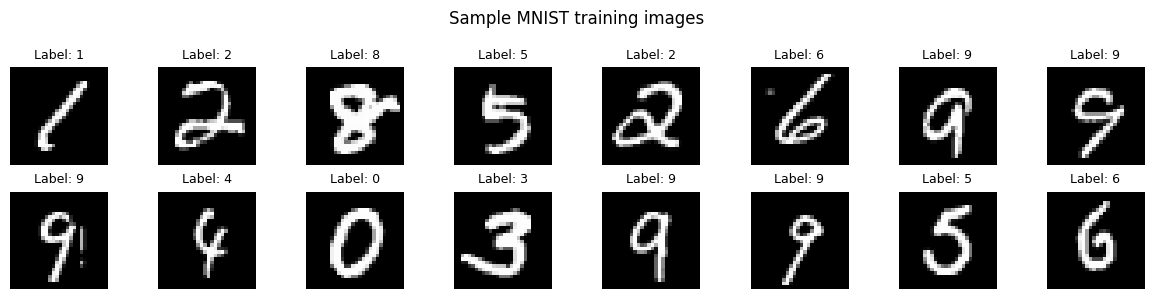

In [4]:
# ── Visualise a few training samples ──────────────────────────────────────
examples = iter(train_loader)
images, labels = next(examples)

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(f'Label: {labels[i].item()}', fontsize=9)
    ax.axis('off')
plt.suptitle('Sample MNIST training images', fontsize=12)
plt.tight_layout()
plt.show()

In [5]:
# ── Model definition ───────────────────────────────────────────────────────
class OneHiddenLayerNet(nn.Module):
    """
    Input(784) --> Linear(256) --> ReLU --> Linear(10)

    Design choices:
      - Flatten  : 28x28 images -> 784-dim vectors
      - Hidden   : 256 units with ReLU (avoids vanishing gradients)
      - Output   : 10 raw logits (CrossEntropyLoss applies softmax internally)
    """
    def __init__(self, input_size=784, hidden_size=HIDDEN_SIZE, num_classes=10):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1     = nn.Linear(input_size, hidden_size)   # 784 -> 256
        self.relu    = nn.ReLU()
        self.fc2     = nn.Linear(hidden_size, num_classes)  # 256 -> 10

    def forward(self, x):
        x = self.flatten(x)   # (B, 1, 28, 28) -> (B, 784)
        x = self.fc1(x)       # (B, 784)  -> (B, 256)
        x = self.relu(x)      # element-wise non-linearity
        x = self.fc2(x)       # (B, 256)  -> (B, 10)  raw logits
        return x

model = OneHiddenLayerNet().to(device)
print(model)

total_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal trainable parameters: {total_params:,}')
print(f'  fc1 (784->256): {784*256 + 256:,}  (weights + biases)')
print(f'  fc2 (256->10) : {256*10  + 10:,}  (weights + biases)')

OneHiddenLayerNet(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)

Total trainable parameters: 203,530
  fc1 (784->256): 200,960  (weights + biases)
  fc2 (256->10) : 2,570  (weights + biases)


In [6]:
# ── Loss function and optimizer ────────────────────────────────────────────
# CrossEntropyLoss = log-softmax + NLL loss (applies softmax internally)
criterion = nn.CrossEntropyLoss()

# Adam: combines Momentum + RMSProp (Lecture 10, Section 5.4)
# beta1=0.9  -> first moment (gradient direction, like momentum)
# beta2=0.999 -> second moment (gradient magnitude, like RMSProp)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE,
                       betas=(0.9, 0.999), eps=1e-8)

print(f'Loss     : {criterion}')
print(f'Optimizer: {optimizer.__class__.__name__}  (lr={LEARNING_RATE}, beta1=0.9, beta2=0.999)')

Loss     : CrossEntropyLoss()
Optimizer: Adam  (lr=0.001, beta1=0.9, beta2=0.999)


In [7]:
# ── Training and evaluation helpers ───────────────────────────────────────
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()                    # clear old gradients
        outputs = model(images)                  # forward pass
        loss    = criterion(outputs, labels)     # compute loss
        loss.backward()                          # backpropagation
        optimizer.step()                         # update weights
        running_loss += loss.item() * images.size(0)
        _, predicted  = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)
    return running_loss / total, 100. * correct / total

def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted  = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total   += labels.size(0)
    return running_loss / total, 100. * correct / total

print('Helper functions defined.')

Helper functions defined.


In [8]:
# ── Training loop ─────────────────────────────────────────────────────────
print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Train Acc":>9} | {"Val Loss":>8} | {"Val Acc":>8}')
print('='*58)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss,   val_acc   = evaluate(model,   test_loader,  criterion)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f'{epoch:>6} | {train_loss:>10.4f} | {train_acc:>8.2f}% | {val_loss:>8.4f} | {val_acc:>7.2f}%')

print('='*58)

 Epoch | Train Loss | Train Acc | Val Loss |  Val Acc
     1 |     0.2297 |    93.30% |   0.1160 |   96.25%
     2 |     0.0945 |    97.13% |   0.0914 |   97.16%
     3 |     0.0631 |    98.03% |   0.0772 |   97.61%
     4 |     0.0483 |    98.45% |   0.0808 |   97.56%
     5 |     0.0359 |    98.84% |   0.0690 |   97.98%
     6 |     0.0301 |    99.00% |   0.0877 |   97.43%
     7 |     0.0257 |    99.13% |   0.0787 |   97.84%
     8 |     0.0208 |    99.29% |   0.0812 |   97.96%
     9 |     0.0169 |    99.44% |   0.0958 |   97.48%
    10 |     0.0165 |    99.43% |   0.0883 |   97.84%


In [9]:
# ── Final evaluation ───────────────────────────────────────────────────────
final_val_loss, final_val_acc = evaluate(model, test_loader, criterion)
print(f'Final Test Accuracy : {final_val_acc:.2f}%')
print(f'Final Test Loss     : {final_val_loss:.4f}')

# Per-class accuracy
print('\nPer-class accuracy:')
class_correct = [0]*10
class_total   = [0]*10
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        _, predicted = model(images).max(1)
        for i in range(len(labels)):
            lbl = labels[i].item()
            class_correct[lbl] += (predicted[i] == labels[i]).item()
            class_total[lbl]   += 1

for digit in range(10):
    acc = 100 * class_correct[digit] / class_total[digit]
    print(f'  Digit {digit}: {acc:.1f}%  ({class_correct[digit]}/{class_total[digit]})')

Final Test Accuracy : 97.84%
Final Test Loss     : 0.0883

Per-class accuracy:
  Digit 0: 99.3%  (973/980)
  Digit 1: 99.1%  (1125/1135)
  Digit 2: 97.2%  (1003/1032)
  Digit 3: 97.2%  (982/1010)
  Digit 4: 99.0%  (972/982)
  Digit 5: 95.9%  (855/892)
  Digit 6: 98.2%  (941/958)
  Digit 7: 97.8%  (1005/1028)
  Digit 8: 97.6%  (951/974)
  Digit 9: 96.8%  (977/1009)


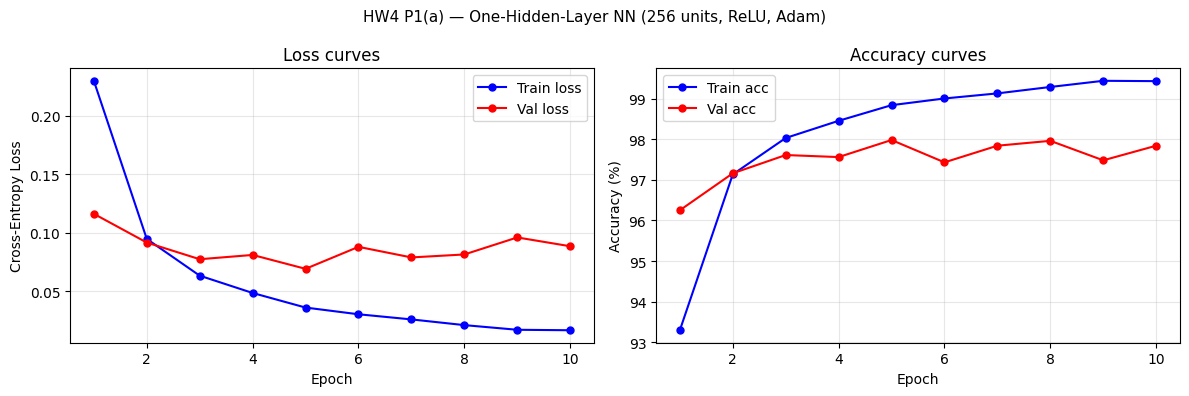

Figure saved as hw4_p1a_learning_curves.png


In [10]:
# ── Learning curves ────────────────────────────────────────────────────────
epochs = range(1, NUM_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, history['train_loss'], 'b-o', label='Train loss', markersize=5)
ax1.plot(epochs, history['val_loss'],   'r-o', label='Val loss',   markersize=5)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Cross-Entropy Loss')
ax1.set_title('Loss curves'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs, history['train_acc'], 'b-o', label='Train acc', markersize=5)
ax2.plot(epochs, history['val_acc'],   'r-o', label='Val acc',   markersize=5)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy curves'); ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('HW4 P1(a) — One-Hidden-Layer NN (256 units, ReLU, Adam)', fontsize=11)
plt.tight_layout()
plt.savefig('hw4_p1a_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as hw4_p1a_learning_curves.png')